In [1]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [2]:
# Define paths to the dataset
train_dir = '/content/drive/MyDrive/train'  # Update with your actual path
test_dir = '/content/drive/MyDrive/test'    # Update with your actual path

In [3]:
import os
print(len(os.listdir('/content/drive/MyDrive/train/horses')))
print(len(os.listdir('/content/drive/MyDrive/train/humans')))
print(len(os.listdir('/content/drive/MyDrive/test/horses')))
print(len(os.listdir('/content/drive/MyDrive/test/humans')))

500
527
500
527


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 822 images belonging to 2 classes.
Found 205 images belonging to 2 classes.


In [5]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [10]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output laye

In [11]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification


In [12]:
history = model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 350s 13s/step - accuracy: 0.7287 - loss: 0.6352 - val_accuracy: 0.9268 - val_loss: 0.2065
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 157s 6s/step - accuracy: 0.9599 - loss: 0.1112 - val_accuracy: 0.8976 - val_loss: 0.1763
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.8829 - val_loss: 0.2581
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 203s 6s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9463 - val_loss: 0.1138
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 1.0000 - loss: 6.2340e-04 - val_accuracy: 0.9463 - val_loss: 0.1295


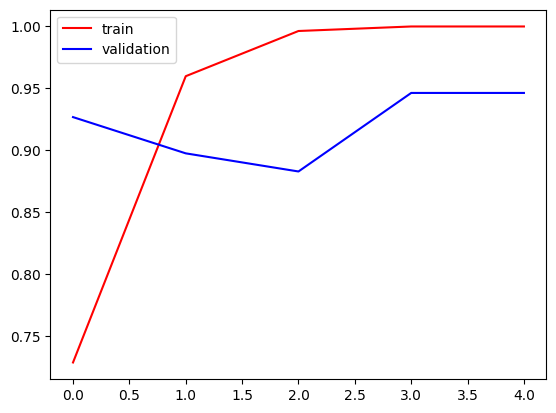

In [13]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

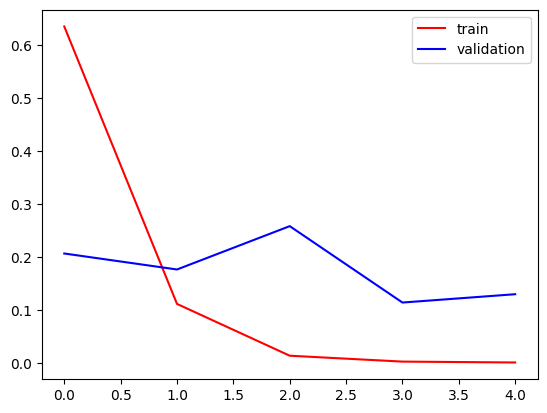

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [15]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 1027 images belonging to 2 classes.


In [16]:
predictions = model.predict(test_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 178s 5s/step


In [17]:
from sklearn.metrics import confusion_matrix, classification_report


true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)


cm = confusion_matrix(true_labels, predicted_labels)


print("Confusion Matrix:")
print(cm)


print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[261 239]
 [250 277]]
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.52      0.52       500
           1       0.54      0.53      0.53       527

    accuracy                           0.52      1027
   macro avg       0.52      0.52      0.52      1027
weighted avg       0.52      0.52      0.52      1027



In [18]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:

from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [20]:
history = model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 250s 9s/step - accuracy: 0.9088 - loss: 1.4273 - val_accuracy: 0.5122 - val_loss: 25.9531
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 235s 9s/step - accuracy: 0.9659 - loss: 0.5565 - val_accuracy: 0.5122 - val_loss: 35.4230
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 243s 9s/step - accuracy: 0.9903 - loss: 0.1484 - val_accuracy: 0.5122 - val_loss: 47.0083
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 243s 9s/step - accuracy: 0.9903 - loss: 0.1484 - val_accuracy: 0.5122 - val_loss: 42.1455
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 224s 9s/step - accuracy: 0.9951 - loss: 0.1181 - val_accuracy: 0.5122 - val_loss: 25.0413


In [21]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)


Found 1027 images belonging to 2 classes.


In [22]:
predictions = model.predict(test_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[  0 500]
 [  0 527]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       500
           1       0.51      1.00      0.68       527

    accuracy                           0.51      1027
   macro avg       0.26      0.50      0.34      1027
weighted avg       0.26      0.51      0.35      1027



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [25]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])


In [26]:
history = resnet_model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 315s 12s/step - accuracy: 0.5620 - loss: 2.5131 - val_accuracy: 0.5024 - val_loss: 0.9892
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 313s 11s/step - accuracy: 0.7835 - loss: 0.5040 - val_accuracy: 0.6829 - val_loss: 0.5243
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 320s 12s/step - accuracy: 0.8929 - loss: 0.3029 - val_accuracy: 0.8146 - val_loss: 0.3733
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 300s 12s/step - accuracy: 0.8759 - loss: 0.2916 - val_accuracy: 0.7707 - val_loss: 0.3722
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 321s 11s/step - accuracy: 0.8954 - loss: 0.2650 - val_accuracy: 0.7415 - val_loss: 0.4431


In [27]:
predictions = resnet_model.predict(test_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 306s 9s/step


In [28]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[263 237]
 [294 233]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.47      0.53      0.50       500
           1       0.50      0.44      0.47       527

    accuracy                           0.48      1027
   macro avg       0.48      0.48      0.48      1027
weighted avg       0.48      0.48      0.48      1027

